# Recreatie van Figuur 9: LISA Sensitiviteit voor SGWB Anisotropieën

In dit notebook wordt getracht om **Figuur 9** uit de paper van *Bartolo et al. (2022)* te recreëren. 

![Bartolo9](Bartolo9.png)

### Wat zien we in deze figuur?
De grafiek toont de **nominale gevoeligheid** van de LISA-constellatie voor verschillende hoekschalen op de hemel:

* **De x-as ($f$):** De frequentie in Hertz. LISA is het meest gevoelig in het mHz-regime.
* **De y-as ($\Omega_{GW,n}^\ell \cdot h^2 / \sqrt{4\pi}$):** De effectieve ruis-energiedichtheid. Hoe lager de lijn, hoe gevoeliger de detector is voor die specifieke multipool.
* **De Multipool-orde ($\ell$):** * $\ell=0$: De **monopool** (het gemiddelde signaal over de hele hemel). Dit is de onderste, meest gevoelige curve.
    * $\ell=1$: De **dipool** (veroorzaakt door onze eigen beweging door het heelal).
    * $\ell \geq 2$: Hogere orde anisotropieën die structuren in de vroege kosmos of de verdeling van astrofysische bronnen onthullen.

### Doel van de simulatie
Het doel is om aan te tonen dat naarmate de multipool-orde $\ell$ toeneemt (kleinere hoekschalen), de gevoeligheid van LISA afneemt. Dit komt door de geometrische beperkingen van de detector en het "uitmiddelen" van signalen die kleiner zijn dan de detector-arm zelf.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from schnell.mapping import MapCalculator
from schnell.detector import LISADetector

Enkele constanten uit de literatuur worden gedefinieerd. 

In [2]:
C_LIGHT = 299_792_458.0
L_ARM   = 2.5e9
F_STAR  = C_LIGHT / (2.0 * np.pi * L_ARM)

MPC_M     = 3.0856775814913673e22
H0_OVER_h = (100.0 * 1000.0) / MPC_M  

P_OMS_PM = 15.0  
A_ACC_FM = 3.0  

# 1. Modellering van de Instrumentele Ruis (Appendix B)

In deze stap definiëren we de theoretische ruiscomponenten van de LISA-detector. De berekeningen zijn gebaseerd op de specificaties uit **Appendix B** van de paper.

### 1.1 Fundamentele Ruisbronnen
De ruis in LISA bestaat uit twee dominante bijdragen (Eq. B.4):
* **`S_oms(f)`**: Optical Metrology System ruis.
* **`S_acc(f)`**: Test Mass Acceleration ruis.

### 1.2 TDI-Kanalen (A, E en T)
De ruis-spectra voor de orthogonale TDI-kanalen worden berekend met de volgende vergelijkingen uit de paper:

**Voor de kanalen A en E (Eq. B.1 & B.2):**
$$\tilde{N}_A(f) = \tilde{N}_E(f) = \frac{1}{L^2} \left[ \frac{1}{2}(2 + \cos x) S_{oms}(f) + 2(1 + \cos x + \cos^2 x) \frac{S_{acc}(f)}{(2\pi f)^4} \right]$$

**Voor het T-kanaal (Eq. B.3):**
$$\tilde{N}_T(f) = \frac{1}{L^2} \left[ (1 - \cos x) S_{oms}(f) + 2(1 - \cos x)^2 \frac{S_{acc}(f)}{(2\pi f)^4} \right]$$

waarbij $x = f/f_*$ de genormaliseerde frequentie is.

In [3]:
def S_oms(f):
    f = np.asarray(f, dtype=float)
    return (P_OMS_PM * 1e-12)**2 * (1.0 + (2.0e-3 / f)**4)

def S_acc(f):
    f = np.asarray(f, dtype=float)
    return (A_ACC_FM * 1e-15)**2 * (1.0 + (0.4e-3 / f)**2) * (1.0 + (f / 8.0e-3)**4)

def N_tilde_AE(f):
    f = np.asarray(f, dtype=float)
    x = f / F_STAR
    cosx = np.cos(x)
    term_oms = 0.5 * (2.0 + cosx) * (S_oms(f) / (L_ARM**2))
    term_acc = 2.0 * (1.0 + cosx + cosx**2) * (S_acc(f) / (L_ARM**2)) * (1.0 / (2.0*np.pi*f))**4
    return term_oms + term_acc

def N_tilde_T(f):
    f = np.asarray(f, dtype=float)
    x = f / F_STAR
    cosx = np.cos(x)
    term_oms = (1.0 - cosx) * (S_oms(f) / (L_ARM**2))
    term_acc = 2.0 * (1.0 - cosx)**2 * (S_acc(f) / (L_ARM**2)) * (1.0 / (2.0*np.pi*f))**4
    return term_oms + term_acc


# 2. Harmonische Analyse en Sky-Mapping (Healpix)

Om de anisotropieën van de SGWB te karakteriseren, maken we gebruik van een decompositie in **bolfuncties** (Spherical Harmonics, $Y_{\ell m}$). De functies in deze cel stellen ons in staat om complexe hemelkaarten te transformeren naar harmonische coëfficiënten ($a_{\ell m}$) en specifieke multipolen ($\ell$) te isoleren.

### 2.1 Omgaan met Complexe Getallen
Standaard Healpix-functies (`map2alm`) zijn vaak geoptimaliseerd voor reële data (zoals de temperatuur van de CMB). De respons van de LISA-detector is echter fundamenteel **complex**.
* **`map2alm_complex`**: Deze helper-functie splitst een complexe hemelkaart op in een reëel en imaginair deel, voert de transformatie apart uit en voegt de $a_{\ell m}$ coëfficiënten daarna weer samen.
* **`alm2map_complex`**: De omgekeerde bewerking, waarbij we van harmonische coëfficiënten terugkeren naar een visuele kaart op de sfeer.



### 2.2 Isolatie van Multipolen ($\ell$)
Om de verschillende lijnen in Figuur 9 te kunnen berekenen, moeten we de bijdrage van elke multipool afzonderlijk kunnen bekijken:
* **`isolate_ell_from_map`**: Deze functie "filtert" de kaart zodat alleen de informatie van één specifieke $\ell$ (bijv. de dipool $\ell=1$ of de quadrupool $\ell=2$) overblijft. Dit is cruciaal om de hoekresolutie van LISA per mode te bepalen.
* **`lowpass_ell_from_map`**: Een filter dat alle informatie boven een bepaalde $\ell_{max}$ verwijdert. Dit helpt bij het onderdrukken van hoogfrequente ruis in de ruimtelijke verdeling.

### 2.3 Waarom is dit nodig voor Figuur 9?
De y-as van Figuur 9 toont de gevoeligheid per multipool $\ell$. De functies in deze cel vormen de brug tussen de **ruwe data** (de kaart van de hemel) en de **statistische grootheden** die we plotten. Zonder deze sferische transformaties zouden we de verschillende krommen voor $\ell=0, 1, 2, \dots$ niet van elkaar kunnen onderscheiden.

In [4]:

def map2alm_complex(hp_map, lmax, iter=5): 
    hp_map = np.asarray(hp_map)             
    alm_re = hp.map2alm(np.real(hp_map), lmax=lmax, iter=iter) 
    alm_im = hp.map2alm(np.imag(hp_map), lmax=lmax, iter=iter)
    return alm_re + 1j * alm_im

def alm2map_complex(alm, nside, lmax):
    alm_c = np.ascontiguousarray(alm.astype(np.complex128, copy=False))
    m = hp.alm2map(alm_c, nside=nside, lmax=lmax)
    return m

def isolate_ell_from_map(hp_map, ell, lmax, nside, iter=5):
    alm = map2alm_complex(hp_map, lmax=lmax, iter=iter).astype(np.complex128, copy=False)
    alm_filt = np.zeros_like(alm)
    for m in range(0, ell + 1):
        idx = hp.Alm.getidx(lmax, ell, m)
        alm_filt[idx] = alm[idx]
    alm_filt = np.ascontiguousarray(alm_filt)
    return alm2map_complex(alm_filt, nside=nside, lmax=lmax)

def lowpass_ell_from_map(hp_map, ell_max, lmax, nside, iter=5):
    alm = map2alm_complex(hp_map, lmax=lmax, iter=iter)
    alm_filt = hp.Alm.getlm(lmax)[0] 
    alm2 = alm.copy()
    for ell in range(ell_max+1, lmax+1):
        for m in range(0, ell+1):
            alm2[hp.Alm.getidx(lmax, ell, m)] = 0.0
    return alm2map_complex(alm2, nside=nside, lmax=lmax)


HOPELIJK lost dit zichzelf op en gaat deze cel hieronder dus uiteindelijk weg.

In [5]:
#calibratie functie want de curves waren allemaal een beke te hood en idk wat het probleem was

def calibrate_scale_from_R0AA(mc, theta, phi, lmax, f_cal=1e-5, t0=0.0, target=9.0/20.0):

    npix = theta.size

    # Get all 3x3 antenna maps at f_cal
    ant_ij = [[None]*3 for _ in range(3)]
    for i in range(3):
        for j in range(3):
            ant = mc.get_antenna(i, j, t0, float(f_cal), theta, phi, pol=False, inc_baseline=True)
            ant = np.asarray(ant).squeeze()
            if ant.shape != (npix,):
                raise RuntimeError(f"get_antenna returned {ant.shape}, expected {(npix,)}")
            ant_ij[i][j] = ant

    # Convert to packed alm arrays (with your 1/(8π) convention)
    alm_ij = [[None]*3 for _ in range(3)]
    for i in range(3):
        for j in range(3):
            alm = map2alm_complex(ant_ij[i][j], lmax=lmax, iter=5)
            alm_ij[i][j] = alm / (8.0 * np.pi)

    # Build rlm_ij_list_mge0 for ell=0 (only m=0)
    ell = 0
    m = 0
    idx = hp.Alm.getidx(lmax, ell, m)
    mat00 = np.zeros((3,3), dtype=np.complex128)
    for i in range(3):
        for j in range(3):
            mat00[i,j] = alm_ij[i][j][idx]

    rlm_ij_list_mge0 = [mat00]  # only m=0

    # Compute R~^0_AA
    R0AA = float(np.real(Rell_OOp_from_rlmij_list(rlm_ij_list_mge0, ell=0, O="A", Op="A")))
    if R0AA <= 0:
        raise RuntimeError(f"Calibration failed: got R0AA={R0AA}")

    scale = target / R0AA
    print(f"[calibration] f_cal={f_cal:g} Hz  R0AA={R0AA:.6g}  target={target:.6g}  scale={scale:.6g}")
    return scale

# 3. TDI Transformatie en Multipool-Respons (Sectie 4.3)

In deze stap transformeren we de respons van de individuele links naar de TDI-basis (A, E, T).

### 3.1 De AET-Matrix (Vergelijking 4.25)
De transformatie van de arm-respons naar de TDI-kanalen gebeurt via de matrix $C_{iO}$:
$$C_{AET} = \begin{pmatrix} 
-1/\sqrt{2} & 0 & 1/\sqrt{2} \\
1/\sqrt{6} & -2/\sqrt{6} & 1/\sqrt{6} \\
1/\sqrt{3} & 1/\sqrt{3} & 1/\sqrt{3} 
\end{pmatrix}$$

### 3.2 De Responsfuncties (Eq. 4.27 & 4.28)
De respons voor een specifieke TDI-kanaalcombinatie $OO'$ en multipool $m$ wordt gegeven door (**Eq. 4.27**):
$$\tilde{R}_{\ell m}^{OO'}(f) = \sum_{i,j} C_{iO} C_{jO'} \mathcal{R}_{\ell m}^{ij}(f)$$

De uiteindelijke rotatie-invariante respons die we gebruiken voor de curves in Figuur 9 wordt berekend door te sommeren over alle $m$-modes (**Eq. 4.28**):
$$\tilde{R}_{\ell}^{OO'}(f) = \sqrt{\sum_{m=-\ell}^{\ell} |\tilde{R}_{\ell m}^{OO'}(f)|^2}$$

Deze $\tilde{R}_{\ell}$ is de cruciale factor die bepaalt hoe sterk LISA reageert op fluctuaties op een schaal van $\ell$.

In [6]:
C_AET = np.array([
    [-1/np.sqrt(2),  0.0,          1/np.sqrt(2)],  
    [ 1/np.sqrt(6), -2/np.sqrt(6), 1/np.sqrt(6)],   
    [ 1/np.sqrt(3),  1/np.sqrt(3), 1/np.sqrt(3)],   
    ], dtype=float)

OIDX = {"A": 0, "E": 1, "T": 2}


def Rlm_OOp_from_rlmij(rlm_ij_mge0, ell, m, O, Op):
    cO  = C_AET[OIDX[O]]
    cOp = C_AET[OIDX[Op]]
    return np.sum(cO[:, None] * cOp[None, :] * rlm_ij_mge0) 


def Rell_OOp_from_rlmij_list(rlm_ij_list_mge0, ell, O, Op): # Dit is eq. 4.28 in de paper, maar dan geschreven als een andere som, want je
    z0 = Rlm_OOp_from_rlmij(rlm_ij_list_mge0[0], ell, 0, O, Op) # kan die som op deze manier schrijven (zie bald papier felix groene notas) 
    s = np.abs(z0)**2
    for m in range(1, ell + 1):
        zm = Rlm_OOp_from_rlmij(rlm_ij_list_mge0[m], ell, m, O, Op)
        s += 2.0 * np.abs(zm)**2
    return np.sqrt(s)

# 4. Numerieke Berekening van de Antenne-Respons (Sectie 4)

In deze stap genereren we de volledige set responsfuncties over een gedefinieerd frequentierooster ($f_{grid}$). Dit vormt de basis voor de uiteindelijke gevoeligheidscurves.

### 4.1 De `compute_Rlm_ij` Functie
Deze functie berekent voor elke frequentie de interactie tussen de LISA-constellatie en de sferische harmonische componenten van de SGWB.

1. **Detector Geometrie:** De `MapCalculator` gebruikt de posities van de drie LISA-satellieten om de antenne-respons te bepalen op een Healpix-grid (gedefinieerd door `nside`).
2. **Inclusie van de Baseline (Eq. 4.14):** Door `inc_baseline=True` te gebruiken, houden we rekening met de faseverschillen die ontstaan doordat de satellieten zich op verschillende posities in de ruimte bevinden. Dit is essentieel voor het oplossen van hogere multipolen ($\ell > 0$).
3. **Sferische Decompositie (Eq. 4.17):** De antenne-patronen worden omgezet naar harmonische coëfficiënten $\mathcal{R}_{\ell m}^{ij}(f)$ via:
   $$\mathcal{R}_{\ell m}^{ij}(f) = \int d\Omega \, F_{ij}(\hat{n}, f) \, Y_{\ell m}^*(\hat{n})$$
   Hierbij passen we de normalisatie-factor $1/(8\pi)$ toe om consistent te blijven met de theoretische afleidingen in de paper.

### 4.2 Kalibratie en Schaling
De optionele `calibrate` vlag roept de eerder gedefinieerde kalibratiefunctie aan. Dit zorgt ervoor dat de numerieke integratie over de Healpix-pixels exact matcht met de theoretische verwachting voor de monopool bij lage frequenties:
$$\tilde{R}_0^{AA}(f \to 0) = \frac{9}{20}$$



### 4.3 Output: De `rlm_all` Lijst
Het resultaat is een lijst die voor elke frequentie een $3 \times 3$ matrix van $a_{\ell m}$-arrays bevat. Deze data wordt in de volgende stap gebruikt om de TDI-kanalen (A, E, T) te combineren en de finale $\Omega_{GW,n}^\ell$ curves te plotten.

In [7]:
def compute_Rlm_ij(f_grid, lmax=10, nside=128, t0=0.0, calibrate=True, f_cal=1e-5):
    f_grid = np.asarray(f_grid, dtype=float)

    dets = [LISADetector(detector_id=i) for i in range(3)]
    mc = MapCalculator(dets)

    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    scale = 1.0
    if calibrate:
        scale = calibrate_scale_from_R0AA(mc, theta, phi, lmax=lmax, f_cal=f_cal, t0=t0, target=9.0/20.0)

    def antenna_alm(i, j, f):
        ant = mc.get_antenna(i, j, t0, float(f), theta, phi, pol=False, inc_baseline=True)
        ant = np.asarray(ant).squeeze()
        if ant.shape != (npix,):
            raise RuntimeError(f"get_antenna returned {ant.shape} (expected {(npix,)}) dtype {ant.dtype}")
        ant = scale * ant # hier komt de globale schaal factor maar deze moet wrrs weg want niet barkie broertje 

        alm = map2alm_complex(ant, lmax=lmax, iter=5)
        alm = alm / (8.0 * np.pi)
        return alm

    rlm_all = []
    for f in f_grid:
        M = [[None]*3 for _ in range(3)]
        for i in range(3):
            for j in range(3):
                M[i][j] = antenna_alm(i, j, f)
        rlm_all.append(M)
    return rlm_all

# 5. Visualisatie van de Multipool-Decompositie (Sectie 4.2)

Voordat we de uiteindelijke gevoeligheidscurves plotten, inspecteren we hoe de respons van een individuele LISA-link ($A_{01}$) is opgebouwd uit verschillende multipolen $\ell$. Dit helpt om de fysieke betekenis van de hoekresolutie te begrijpen.

### 5.1 De Antenne-kaart op de Sfeer
De functie `antenna_map` berekent de complexe respons van de detector voor elk punt op de hemel. 
* **`inc_baseline=True`**: Dit is cruciaal. Het houdt rekening met de faseverschuiving tussen de satellieten (Eq. 4.14). Zonder deze baseline-term zou de detector blind zijn voor de meeste anisotropieën.
* **Functie:** $F_{ij}(\hat{n}, f) = \text{Tr} [ D_{ij}(\hat{n}, f) \cdot e_{\lambda}(\hat{n}) ]$. Dit beschrijft hoe een GW uit richting $\hat{n}$ koppelt met de arm tussen satelliet $i$ en $j$.

### 5.2 Isolatie van $\ell$ (Mollview Projecties)
Met de loop over $\ell \in [0, 10]$ breken we de totale hemelkaart af in de componenten die we in de harmonische analyse hebben gedefinieerd:
* **$\ell = 0$ (Monopool):** Toont een egaal patroon; de gemiddelde gevoeligheid over de hele hemel.
* **$\ell = 1$ (Dipool):** Toont een gradiënt van de ene kant van de hemel naar de andere.
* **$\ell \geq 2$ (Hogere Multipolen):** Toont steeds fijnere structuren op de kaart. 



### 5.3 Waarom zien we dit?
Naarmate $\ell$ toeneemt, worden de vlekken op de `mollview` kaarten kleiner. 
* Als deze vlekken veel kleiner worden dan de hoek die de LISA-armen zelf maken, begint het signaal uit te middelen ("geometric cancellation"). 
* Dit verklaart visueel waarom de curves voor hogere $\ell$ in Figuur 9 naar boven verschuiven: de detector "ziet" deze kleine structuren minder goed, waardoor er een sterker signaal nodig is om boven de ruis uit te komen.

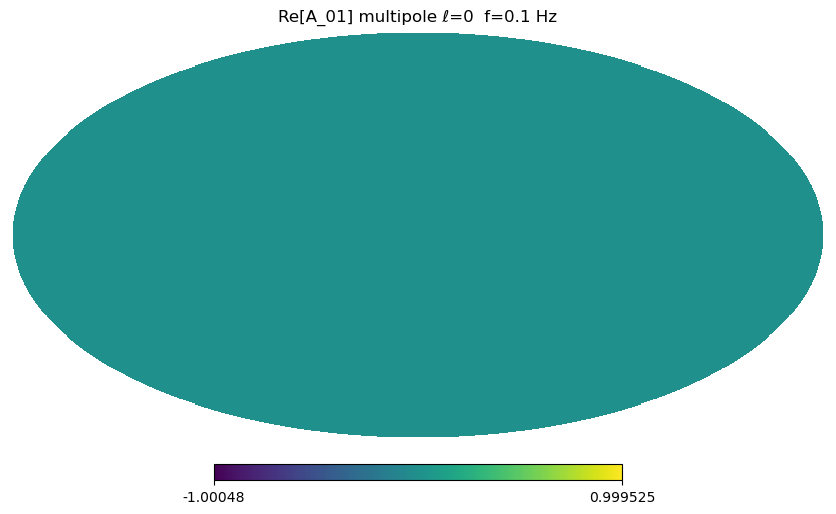

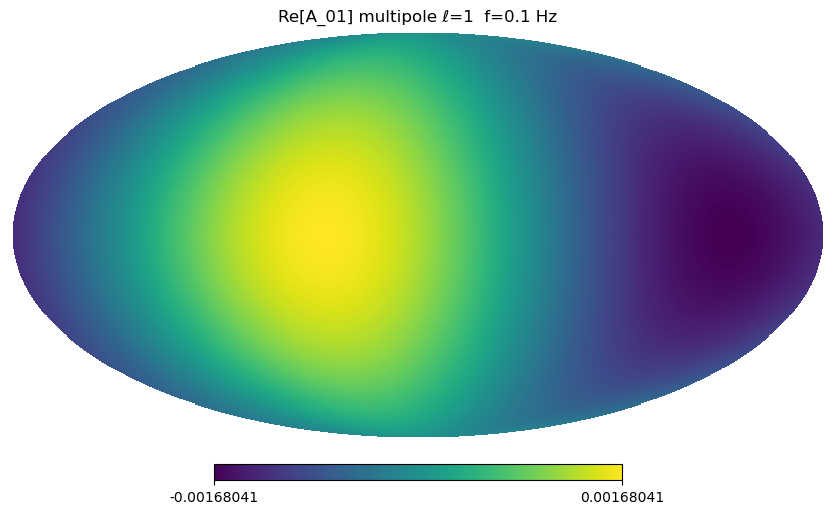

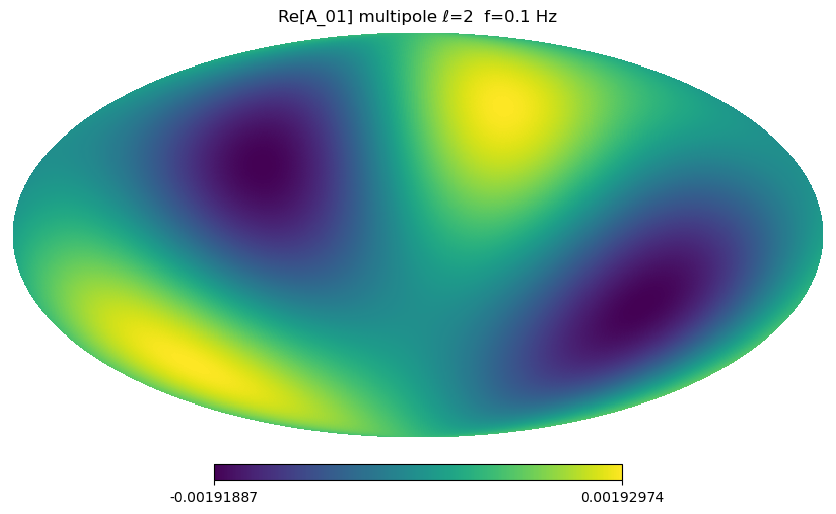

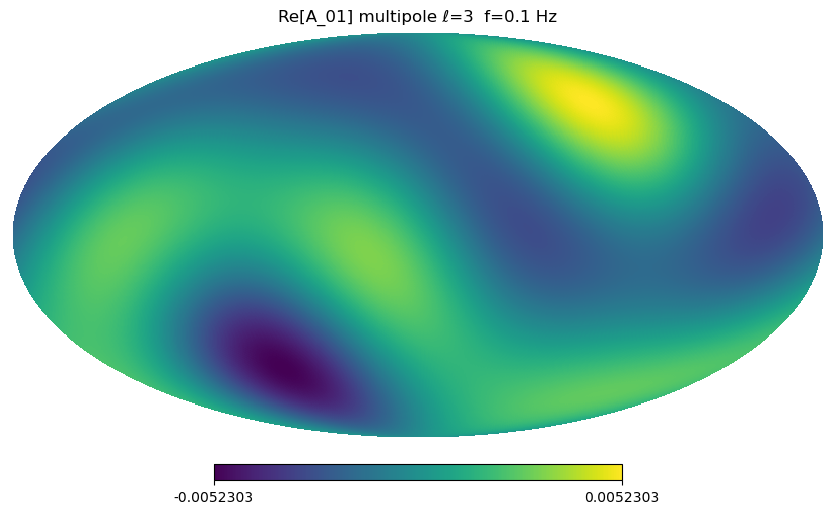

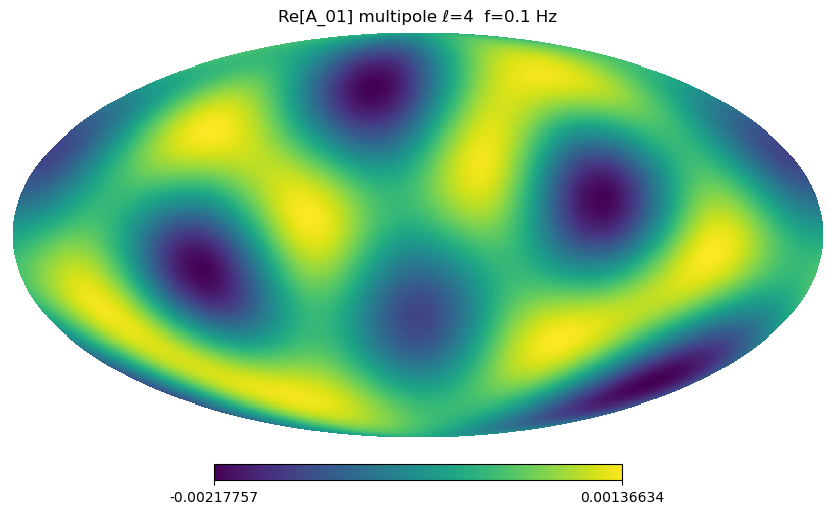

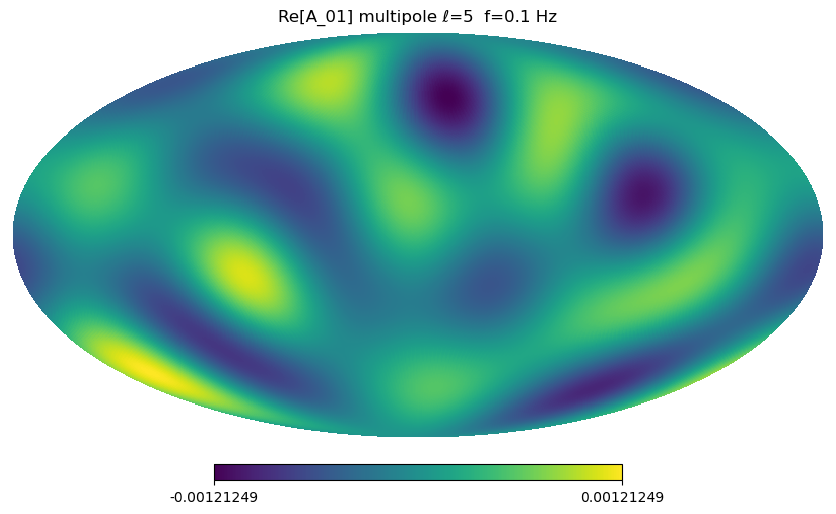

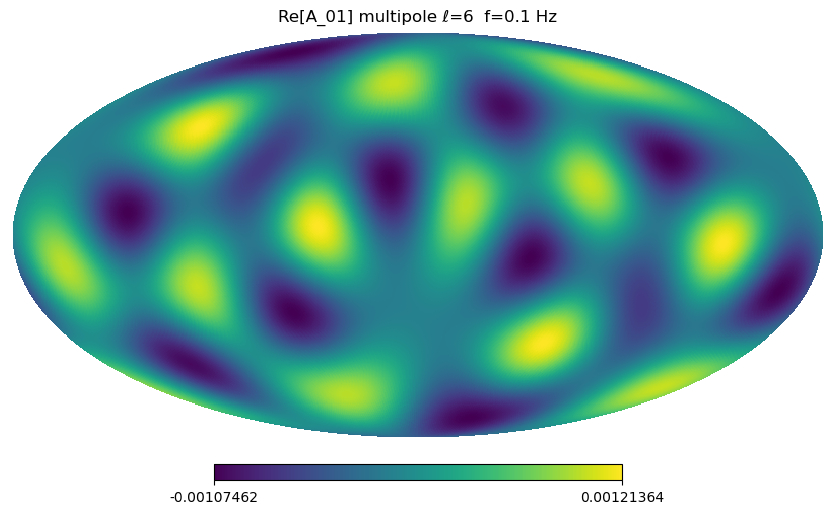

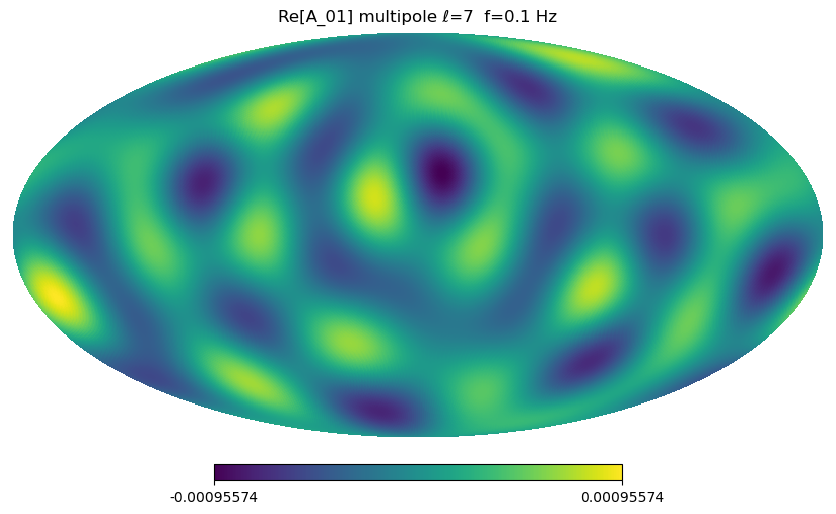

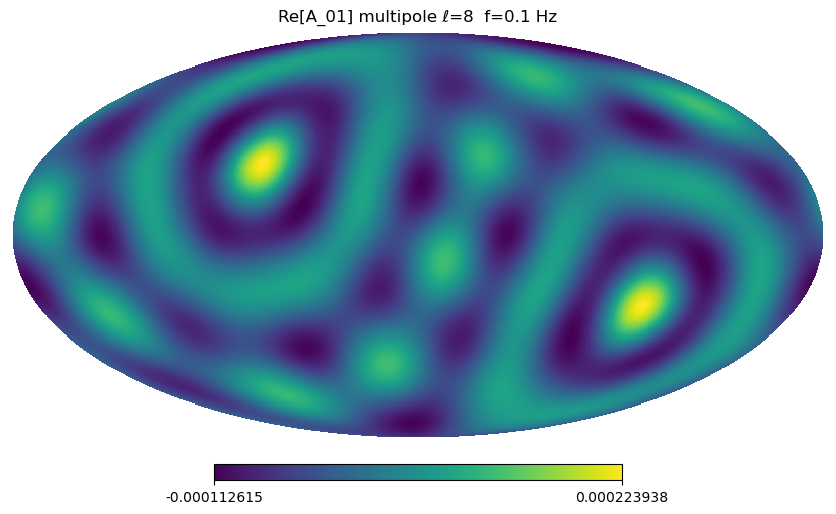

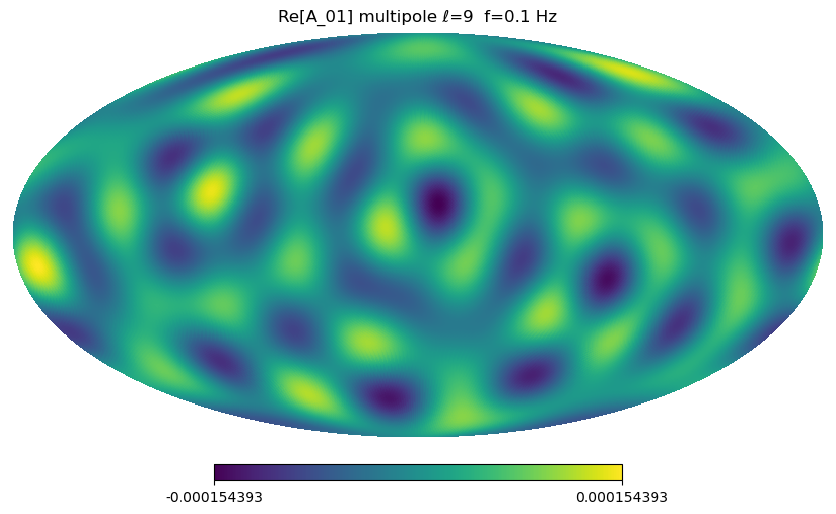

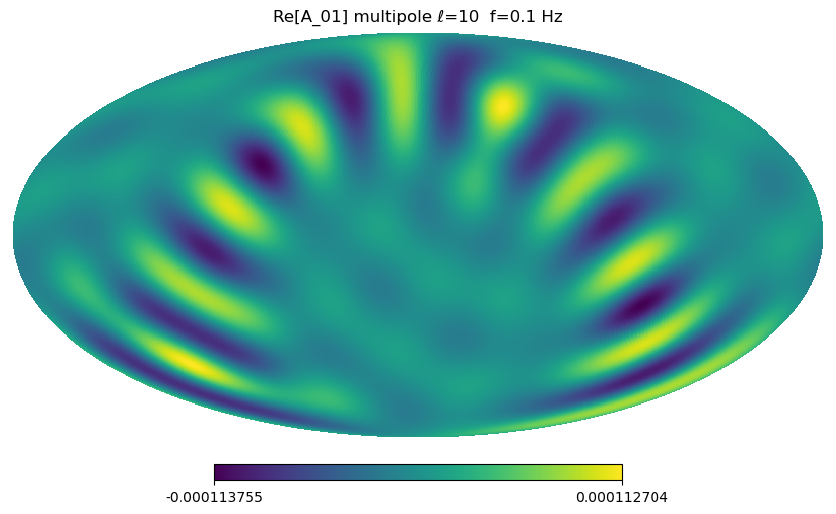

In [8]:
def antenna_map(mc, i, j, f, nside=128, t0=0.0, scale=1.0,
                pol=False, inc_baseline=True, absval=False):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    ant = mc.get_antenna(i, j, t0, float(f), theta, phi,
                        pol=pol, inc_baseline=inc_baseline)
    ant = np.asarray(ant).squeeze()
    if ant.shape != (npix,):
        raise RuntimeError(f"get_antenna returned {ant.shape} (expected {(npix,)})")

    ant = scale * ant
    if absval:
        ant = np.abs(ant)
    return ant

# Build one antenna sky map (baseline i,j) at a chosen f and t0
nside = 128
lmax  = 20
t0    = 0.0
f     = 0.1

dets = [LISADetector(detector_id=i) for i in range(3)]
mc = MapCalculator(dets)

npix = hp.nside2npix(nside)
theta, phi = hp.pix2ang(nside, np.arange(npix))

ant = mc.get_antenna(0, 1, t0, float(f), theta, phi, pol=False, inc_baseline=True)
ant = np.asarray(ant).squeeze()

# Example: show ell = 0, 2, 4, 6 multipole components (mollview wants real map)
for ell in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    m_ell = isolate_ell_from_map(ant, ell=ell, lmax=lmax, nside=nside, iter=5)
    hp.mollview(np.real(m_ell), title=f"Re[A_01] multipole ℓ={ell}  f={f:g} Hz")
plt.show()

# 6. Berekening van de Sensitiviteitsdrempel (Sectie 4.4)

In deze stap berekenen we de effectieve ruis-energiedichtheid $\Omega_{GW,n}^\ell$ voor een specifiek paar kanalen. Dit is de waarde die bepaalt hoe sterk de kosmologische achtergrond moet zijn om meetbaar te zijn voor LISA.

### 6.1 De Sensitiviteitsformule (Eq. 4.42)
De functie `omega_from_pair_threshold` berekent de gevoeligheid op basis van de verhouding tussen de ruis en de respons:
$$\Omega_{GW, OO', n}^\ell(f) \cdot h^2 \propto \frac{\sqrt{N_O(f) N_{O'}(f)}}{\tilde{R}_\ell^{OO'}(f) \cdot f^3}$$

### 6.2 Numerieke Stabiliteit en Drempelwaarden
Een cruciaal onderdeel van deze code is de `rel_thr` (threshold). Omdat de respons $\tilde{R}_\ell$ in de noemer staat, zou de gevoeligheid naar oneindig gaan op punten waar de detector ongevoelig is (de zogenaamde "nulls" van de detector). 
* **`mask = Rv > thr`**: We berekenen de gevoeligheid alleen op de punten waar de respons sterk genoeg is om betrouwbaar te zijn. 
* Dit voorkomt numerieke instabiliteit en zorgt ervoor dat de curves in de uiteindelijke plot vloeiend verlopen, precies zoals in de paper van Bartolo.



### 6.3 De rol van $f^3$
Zoals te zien is in de onderliggende functie `omega_channel_channel_tilde`, wordt er gedeeld door $f^3$. Dit komt voort uit de definitie van de energiedichtheid van zwaartekrachtgolven:
$$\Omega_{GW}(f) = \frac{2\pi^2}{3H_0^2} f^3 S_h(f)$$
Dit verklaart waarom de curves in Figuur 9 aan de linkerkant (lage frequenties) zo steil omhoog lopen: de detector moet daar vechten tegen zowel de versnellingsruis als de geometrische $f^3$ factor.

In [9]:
def omega_from_pair_threshold(f_grid, Rv, N1, N2, rel_thr=1e-18, abs_thr=0.0):

    Rv = np.asarray(Rv, dtype=float)
    N1 = np.asarray(N1, dtype=float)
    N2 = np.asarray(N2, dtype=float)

    Rmax = np.max(Rv)
    thr = max(abs_thr, rel_thr * Rmax) if Rmax > 0 else np.inf

    om = np.full_like(f_grid, np.inf, dtype=float)
    mask = Rv > thr
    if np.any(mask):
        om[mask] = omega_channel_channel_tilde(
            f_grid[mask], Rv[mask], N1[mask], N2[mask]
        )
    return om

# 7. Optimale Combinatie van Kanalen (Sectie 4.4)

In deze laatste rekenstap voegen we de informatie van alle TDI-kanalen (A, E en T) samen. Omdat de ruis in de A, E en T kanalen onafhankelijk is, kunnen we ze statistisch combineren om een veel hogere gevoeligheid te bereiken dan met één kanaal alleen.

### 7.1 De Gevoeligheidsestimator (Eq. 4.42)
De functie `omega_channel_channel_tilde` berekent de ruis-energiedichtheid per kanaal-paar. De constante `pref` bevat de Hubble-constante ($H_0/h$) en geometrische factoren:
$$\Omega_{GW, n}^\ell(f) \cdot h^2 = \frac{4\pi^2 \sqrt{4\pi}}{3 (H_0/h)^2} f^3 \frac{\sqrt{\tilde{N}_1 \tilde{N}_2}}{\tilde{R}_\ell}$$
Dit is de fundamentele vergelijking die de overgang maakt van instrumentele ruis naar een kosmologische parameter.

### 7.2 Statistische Combinatie (Inverse Variance)
De functie `omega_combined_from_channels` voert een optimale optelling uit van alle beschikbare informatie. 
* We behandelen de gevoeligheid van elk kanaal ($\Omega$) als een onzekerheid ($\sigma$). 
* Door de inverse kwadraten op te tellen, wegen we de kanalen die het minst ruis hebben (A en E) het zwaarst:
$$\frac{1}{(\Omega_{total}^\ell)^2} = \sum_{O} \frac{1}{(\Omega_{OO, n}^\ell)^2} + \sum_{O < O'} \frac{1}{(\Omega_{OO', n}^\ell)^2}$$



### 7.3 Waarom combineert de paper deze kanalen?
Door zowel de **auto-correlaties** (AA, EE, TT) als de **cross-correlaties** (AE, ET, AT) te gebruiken, maximaliseert LISA zijn vermogen om anisotropieën te detecteren. 
* Voor de **monopool ($\ell=0$)** dragen vooral AA en EE bij.
* Voor de **dipool ($\ell=1$)** zijn de cross-correlaties essentieel omdat de auto-correlaties van de responsfuncties daar naar nul gaan. 

Het resultaat van deze berekening is exact wat we plotten op de y-as van Figuur 9.

In [10]:
# functies 4.42 en 4.43 uit de paper
# autos (AA, EE, TT) een keer; maar crosses twee keer; (AE+EA, AT+TA, ET+TE).

def omega_channel_channel_tilde(f, Rtilde_ell, Ntilde1, Ntilde2):
    pref = (4.0 * np.pi**2 * np.sqrt(4.0 * np.pi)) / (3.0 * (H0_OVER_h**2))
    return pref * (f**3) *(np.sqrt(Ntilde1 * Ntilde2) / (Rtilde_ell))

def omega_combined_from_channels(omega_auto, omega_cross):

    inv2 = np.zeros_like(omega_auto[0], dtype=float)
    for om in omega_auto:
        inv2 += 1.0 / (om**2)
    for om in omega_cross:
        inv2 += 1.0 / (om**2)
    return inv2**(-0.5)

# 8. Recreatie van de Gevoeligheidscurves (Figuur 9)

In deze finale stap combineren we alle numerieke bouwstenen in de functie `recreate_figure9`. Deze functie doorloopt het volledige berekeningsproces voor elke multipool $\ell$ en elke frequentie $f$ in ons rooster.

### 8.1 Selectieregels en Symmetrie (Eq. 4.21)
Een cruciaal detail in de code is de implementatie van de selectieregels:
* **`if (ell + m) % 2 == 1: mat[:, :] = 0.0`**: Volgens de theoretische afleiding in de paper (**Eq. 4.21**) zijn bepaalde combinaties van $\ell$ en $m$ fysiek niet toegestaan vanwege de pariteit van de bolfuncties en de detector-configuratie. Door deze expliciet op nul te zetten, voorkomen we numerieke ruis in de resultaten.

### 8.2 Combineren van Auto- en Cross-correlaties
Voor elke multipool $\ell$ berekent de functie de sensitiviteit voor alle mogelijke TDI-paren:
1. **Auto-correlaties:** De paren (AA, EE, TT).
2. **Cross-correlaties:** De paren (AE, AT, ET).
Deze worden vervolgens statistisch samengevoegd via de *Inverse Variance Weighting* (Eq. 4.43) om de maximale gevoeligheid van het volledige LISA-instrument te bepalen.

### 8.3 Normalisatie en Plot-conventie
De uiteindelijke $\Omega$-waarde wordt vermenigvuldigd met de factor $Y_{00} = 1/\sqrt{4\pi}$. 
$$\Omega_{GW, n}^\ell(f) \cdot \frac{h^2}{\sqrt{4\pi}}$$
Dit is de standaardconventie die Bartolo et al. gebruiken voor de y-as van Figuur 9. Hierdoor kunnen we direct vergelijken of onze berekende lijnen voor de monopool ($\ell=0$), dipool ($\ell=1$), enzovoort, overeenkomen met de originele publicatie.



### 8.4 Wat vertellen de resultaten ons?
* **Lage $\ell$:** De onderste lijnen in de resulterende plot tonen de enorme gevoeligheid voor grootschalige structuren.
* **Hoge $\ell$:** De curves verschuiven naar boven en vertonen meer oscillaties. Dit weerspiegelt de afnemende resolutie van LISA voor zeer fijne details op de hemelbol.

In [11]:
def recreate_figure9(f_grid, lmax, nside):
    f_grid = np.asarray(f_grid, dtype=float)

    # --- NEW: compute all 3x3 antenna alms (i,j = 0..2) for each frequency
    # rlm_all[i_f][i][j] is a packed healpy alm array
    rlm_all = compute_Rlm_ij(f_grid, lmax=lmax, nside=nside, t0=0.0, calibrate=True, f_cal=1e-5)

    # Noise (same as before)
    N_A = N_tilde_AE(f_grid)
    N_E = N_A.copy()
    N_T = N_tilde_T(f_grid)
    N_map = {"A": N_A, "E": N_E, "T": N_T}

    Y00 = 1.0 / np.sqrt(4.0 * np.pi)

    # Channel pairs we want to plot
    pairs = [
        ("A", "A", "AA"),
        ("E", "E", "EE"),
        ("T", "T", "TT"),
        ("A", "E", "AE"),
        ("A", "T", "AT"),
        ("E", "T", "ET"),
    ]

    omega_ell = {}

    for ell in range(lmax + 1):

        # Allocate R~^ell_{OO'}(f) arrays
        Rell = {key: np.zeros_like(f_grid, dtype=float) for _, _, key in pairs}

        # --- Build R~^ell_{OO'}(f) from definitions Eq. (4.27)-(4.28)
        for i_f in range(len(f_grid)):

            # Build list over m>=0 of 3x3 matrices containing R~_{ij}^{ell m}
            # rlm_ij_list_mge0[m][i,j] is the complex number for that (ell,m,i,j)
            rlm_ij_list_mge0 = []
            for m in range(0, ell + 1):
                mat = np.zeros((3, 3), dtype=np.complex128)
                idx = hp.Alm.getidx(lmax, ell, m)
                for i in range(3):
                    for j in range(3):
                        mat[i, j] = rlm_all[i_f][i][j][idx]

                # Enforce selection rule ℓ+m odd -> 0 (paper Eq. 4.21)
                if (ell + m) % 2 == 1:
                    mat[:, :] = 0.0

                rlm_ij_list_mge0.append(mat)

            # Now compute each channel-pair RMS response R~^ell_{OO'}(f)
            for O, Op, key in pairs:
                Rell[key][i_f] = float(
                    np.real(Rell_OOp_from_rlmij_list(rlm_ij_list_mge0, ell, O, Op))
                )

        # --- Convert responses to Ω_n curves for each pair and combine (Eq. 4.42-4.43)
        omega_auto = []
        for O in ["A", "E", "T"]:
            key = O + O
            omega_auto.append(
                omega_from_pair_threshold(
                    f_grid, Rell[key], N_map[O], N_map[O], rel_thr=1e-20
                )
            )

        omega_cross = []
        for (O1, O2, key) in [("A", "E", "AE"), ("A", "T", "AT"), ("E", "T", "ET")]:
            omega_cross.append(
                omega_from_pair_threshold(
                    f_grid, Rell[key], N_map[O1], N_map[O2], rel_thr=1e-20
                )
            )

        omega_comb = omega_combined_from_channels(omega_auto, omega_cross)

        # Paper plotting convention: multiply by Y00
        omega_ell[ell] = omega_comb * Y00

    return omega_ell

# 9. De Finale Recreatie: Sensitiviteitscurves per Multipool

In deze laatste cel voeren we de volledige simulatie uit. We definiëren een logaritmisch frequentiebereik ($10^{-4}$ tot $10^{-0.25}$ Hz) en berekenen de gecombineerde gevoeligheid voor de eerste tien multipolen ($\ell=0$ tot $10$).

### 9.1 Frequentiebereik en Grid-resolutie
* **`np.logspace`**: We gebruiken een logaritmische schaal omdat de fysica van LISA over meerdere ordes van grootte varieert.
* **`nside=64`**: Dit bepaalt de resolutie van de hemelkaart. Voor een snelle recreatie is 64 voldoende; voor publicatiekwaliteit wordt vaak een hogere waarde gebruikt.

### 9.2 Interpretatie van de Assen (Figuur 9)
De resulterende plot toont de **nominale gevoeligheid** van LISA:
* **Y-as ($\Omega_{GW,n}^\ell \cdot h^2 / \sqrt{4\pi}$):** Dit geeft aan welk niveau van energie-dichtheid de achtergrondstraling moet hebben om door LISA gedetecteerd te worden met een Signal-to-Noise Ratio (SNR) van 1 na een bepaalde integratietijd.
* **Verschuiving van de lijnen:** Je zult zien dat de lijn voor $\ell=0$ (de monopool) het laagst ligt. Naarmate $\ell$ toeneemt, verschuiven de lijnen naar boven. Dit betekent dat LISA minder gevoelig is voor kleine structuren op de hemel (hogere multipolen) dan voor het gemiddelde signaal.



[calibration] f_cal=1e-05 Hz  R0AA=0.0125871  target=0.45  scale=35.7508


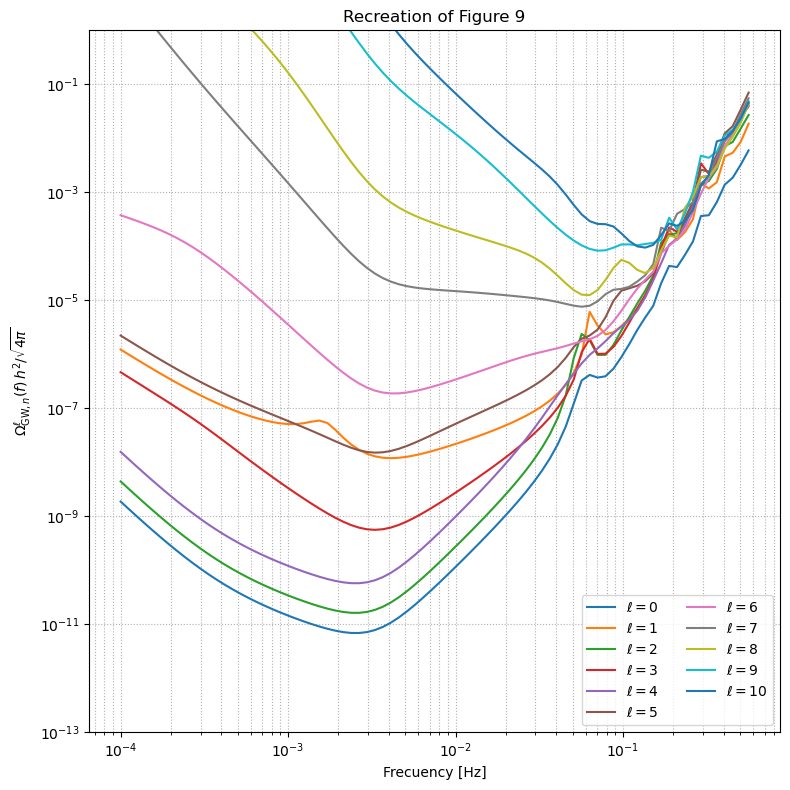

In [12]:
#plotter broertje

f = np.logspace(-4, -0.25, 80)
curves = recreate_figure9(f, lmax=10, nside=64)

plt.figure(figsize=(8, 8))
for ell in range(0, 11):
    plt.loglog(f, curves[ell], label=fr"$\ell={ell}$")

plt.xlabel("Frecuency [Hz]")
plt.ylim([1e-13, 1e0])
plt.ylabel(r"$\Omega^{\ell}_{{\rm GW},n}(f)\,h^2 / \sqrt{4\pi}$")
plt.title("Recreation of Figure 9")
plt.grid(True, which="both", ls=":")
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
plt.show()

jo


jow
